In [ ]:
import os
import scipy.io as sio
import h5py
import numpy as np
from glob import glob

from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import torch

import glob
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
from torch.utils.data import DataLoader
import os


import cv2

In [ ]:
import numpy as np
import h5py
from PIL import Image
import torch
from torchvision import transforms

class CrowdDataset(torch.utils.data.Dataset):
    def __init__(self, img_paths, gt_paths, transform=None):
        self.img_paths = img_paths
        self.gt_paths = gt_paths
        self.transform = transform
        self.gt_transform = transforms.Resize((256, 256))  # resize GT maps to 256x256

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)

        gt_path = self.gt_paths[idx]
        with h5py.File(gt_path, 'r') as f:
            density_map = f['density'][:]

        H_orig, W_orig = density_map.shape
        density_map = density_map.astype(np.float32)
        density_map_img = Image.fromarray(density_map, mode='F')
        density_map_resized_img = self.gt_transform(density_map_img)
        density_map_resized = np.array(density_map_resized_img, dtype=np.float32)
        scale_factor = (H_orig * W_orig) / (256 * 256)
        density_map_resized *= scale_factor
        density_map_resized = torch.from_numpy(density_map_resized).unsqueeze(0)

        return img, density_map_resized


In [ ]:
import os
import glob

root_dir = "/content/drive/MyDrive/work/datasets/ShanghaiTech"
train_img_paths = sorted(glob.glob(os.path.join(root_dir, 'train_data/images/*.jpg')))
val_img_paths = sorted(glob.glob(os.path.join(root_dir, 'test_data/images/*.jpg')))

train_gt_paths = sorted(glob.glob("/content/drive/MyDrive/work/datasets/ShanghaiTech/train_data/ground-truth/*.h5"))
val_gt_paths = sorted(glob.glob("/content/drive/MyDrive/work/datasets/ShanghaiTech/test_data/ground-truth/*.h5"))

# Limit dataset size to first 20 samples
train_img_paths = train_img_paths[:100]
train_gt_paths = train_gt_paths[:100]
val_img_paths = val_img_paths[:100]
val_gt_paths = val_gt_paths[:100]

# Resize to reduce computation
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    # (optional) normalize
])

train_dataset = CrowdDataset(train_img_paths, train_gt_paths, transform)
val_dataset = CrowdDataset(val_img_paths, val_gt_paths, transform)

print("Train images:", len(train_img_paths))
print("Train GTs:", len(train_gt_paths))
print("Val images:", len(val_img_paths))
print("Val GTs:", len(val_gt_paths))

print("Example image path:", train_img_paths[0] if train_img_paths else "None found")
print("Example GT path:", train_gt_paths[0] if train_gt_paths else "None found")

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)  # smaller batch size helps debugging
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)


Train images: 100
Train GTs: 100
Val images: 100
Val GTs: 100
Example image path: /content/drive/MyDrive/work/datasets/ShanghaiTech/train_data/images/IMG_1.jpg
Example GT path: /content/drive/MyDrive/work/datasets/ShanghaiTech/train_data/ground-truth/GT_IMG_1.h5


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MCNN(nn.Module):
    def __init__(self):
        super(MCNN, self).__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(3, 16, 9, padding=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 7, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 16, 7, padding=3),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 8, 7, padding=3),
            nn.ReLU(inplace=True),
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(3, 20, 7, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 40, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(40, 20, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(20, 10, 5, padding=2),
            nn.ReLU(inplace=True),
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(3, 24, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(24, 48, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(48, 24, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(24, 12, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.fuse = nn.Conv2d(8 + 10 + 12, 1, 1)

    def forward(self, x):
        x1 = self.branch1(x)
        x2 = self.branch2(x)
        x3 = self.branch3(x)

        x_cat = torch.cat((x1, x2, x3), 1)
        out = self.fuse(x_cat)
        return out


In [ ]:

def train(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for i, (images, densities) in enumerate(train_loader):
        images = images.to(device)
        densities = densities.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        densities_resized = torch.nn.functional.interpolate(
            densities, size=outputs.shape[2:], mode='bilinear', align_corners=False
        )

        loss = criterion(outputs, densities_resized)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    return avg_loss

def evaluate(model, val_loader, device):
    model.eval()
    mae = 0.0
    with torch.no_grad():
        for images, densities in val_loader:
            images, densities = images.to(device), densities.to(device)
            outputs = model(images)
            mae += torch.abs(outputs.sum() - densities.sum()).item()
    return mae / len(val_loader)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MCNN()
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    print(f"Starting epoch {epoch+1}/{epochs}")

    model.train()
    total_train_loss = 0
    for batch_idx, (images, densities) in enumerate(train_loader, 1):
        images, densities = images.to(device), densities.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        densities_resized = torch.nn.functional.interpolate(densities, size=outputs.shape[2:], mode='bilinear', align_corners=False)
        loss = criterion(outputs, densities_resized)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch+1} average training loss: {avg_train_loss:.4f}")
    model.eval()
    total_mae = 0
    with torch.no_grad():
        for images, densities in val_loader:
            images, densities = images.to(device), densities.to(device)
            outputs = model(images)
            densities_resized = torch.nn.functional.interpolate(
                densities, size=outputs.shape[2:], mode='bilinear', align_corners=False
            )

            mae = torch.abs(outputs.sum() - densities_resized.sum()).item()
            total_mae += mae

    avg_mae = total_mae / len(val_loader)
    print(f"Validation MAE after epoch {epoch+1}: {avg_mae:.4f}\n")


Starting epoch 1/10
Epoch 1 average training loss: 0.0000
Validation MAE after epoch 1: 8.8441

Starting epoch 2/10
Epoch 2 average training loss: 0.0000
Validation MAE after epoch 2: 6.4911

Starting epoch 3/10
Epoch 3 average training loss: 0.0000
Validation MAE after epoch 3: 7.1972

Starting epoch 4/10
Epoch 4 average training loss: 0.0000
Validation MAE after epoch 4: 7.7237

Starting epoch 5/10
Epoch 5 average training loss: 0.0000
Validation MAE after epoch 5: 8.4586

Starting epoch 6/10
Epoch 6 average training loss: 0.0000
Validation MAE after epoch 6: 7.7926

Starting epoch 7/10
Epoch 7 average training loss: 0.0000
Validation MAE after epoch 7: 6.7288

Starting epoch 8/10
Epoch 8 average training loss: 0.0000
Validation MAE after epoch 8: 9.5879

Starting epoch 9/10
Epoch 9 average training loss: 0.0000
Validation MAE after epoch 9: 7.2355

Starting epoch 10/10
Epoch 10 average training loss: 0.0000
Validation MAE after epoch 10: 6.7609



In [ ]:
def test(model, test_loader, device):
    model.eval()
    total_mae = 0
    with torch.no_grad():
        for idx, (images, densities) in enumerate(test_loader):
            images, densities = images.to(device), densities.to(device)
            outputs = model(images)
            mae = torch.abs(outputs.sum() - densities.sum()).item()
            total_mae += mae
            if idx == 0:
                for i in range(min(len(images), 3)):
                    print(f"Sample {i+1} - Predicted count: {outputs[i].sum().item():.2f}, True count: {densities[i].sum().item():.2f}")

    avg_mae = total_mae / len(test_loader)
    print(f"Test MAE: {avg_mae:.4f}")
test(model, val_loader, device)


Sample 1 - Predicted count: 6.86, True count: 23.00
Sample 2 - Predicted count: 7.89, True count: 181.00
Test MAE: 242.1658


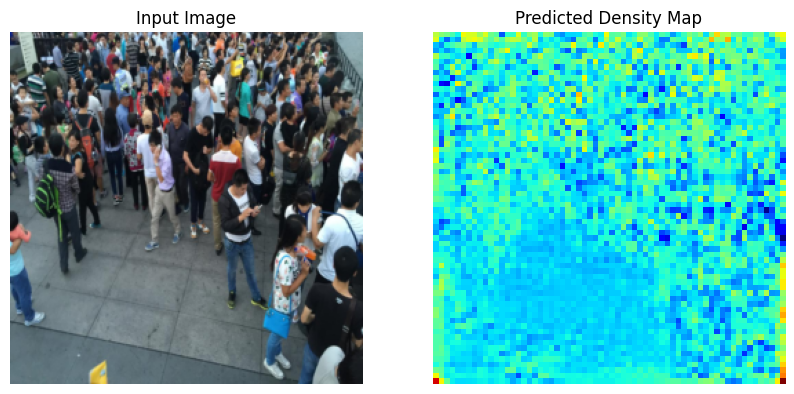

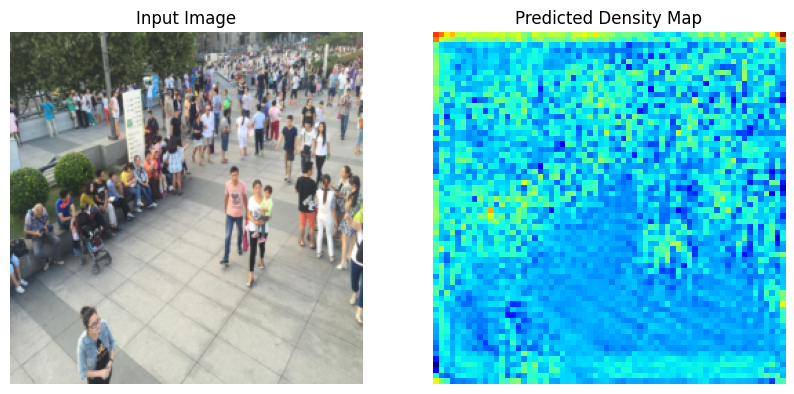

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_prediction(model, test_loader, device, num_images=1):
    model.eval()
    with torch.no_grad():
        for i, (images, densities) in enumerate(test_loader):
            if(i<5):
                continue
            images = images.to(device)
            outputs = model(images)
            outputs_np = outputs.squeeze(1).cpu().numpy()
            images_np = images.cpu().numpy()
            for j in range(min(num_images, images_np.shape[0])):
                img = np.transpose(images_np[j], (1, 2, 0))
                pred_density = outputs_np[j]
                fig, axs = plt.subplots(1, 2, figsize=(10, 5))

                axs[0].imshow(img)
                axs[0].set_title("Input Image")
                axs[0].axis('off')

                axs[1].imshow(pred_density, cmap='jet')
                axs[1].set_title("Predicted Density Map")
                axs[1].axis('off')

                plt.show()


            break

# Usage:
show_prediction(model, val_loader, device, num_images=4)
